In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import shap

In [2]:
import json
import joblib

# Data
X_train = pd.read_csv("../data/X_train.csv")
X_test = pd.read_csv("../data/X_test.csv")

y_train = pd.read_csv("../data/y_train.csv")["Disease"]
y_test = pd.read_csv("../data/y_test.csv")["Disease"]

# Feature sets
with open("../data/feature_sets.json", "r") as f:
    feature_sets = json.load(f)

In [3]:
#recreate the tuned model


from sklearn.ensemble import RandomForestClassifier

features = feature_sets["RF10"]

Xtr = X_train[features]
Xte = X_test[features]

best_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    max_features="sqrt",
    min_samples_leaf=4,
    min_samples_split=2,
    random_state=42
)

best_rf.fit(Xtr, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

In [4]:
#compute the shap values
explainer = shap.TreeExplainer(best_rf)

shap_values = explainer.shap_values(Xte)

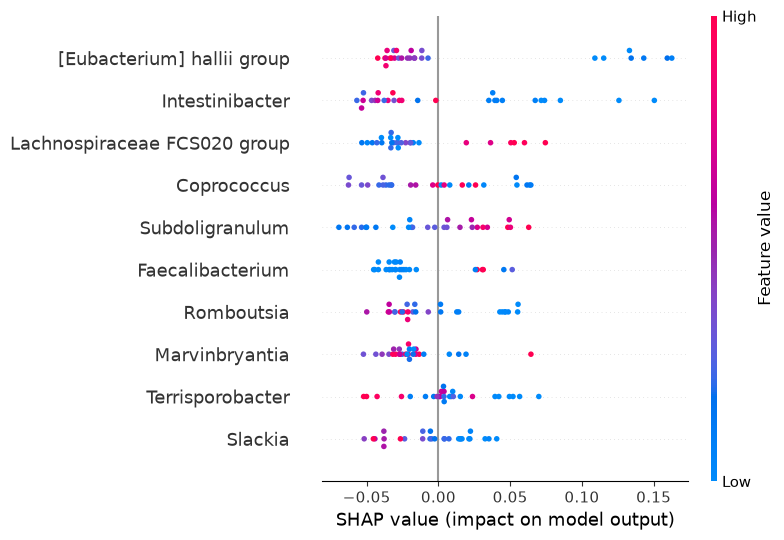

In [5]:
shap.summary_plot(
    shap_values[:, :, 1],
    Xte
)

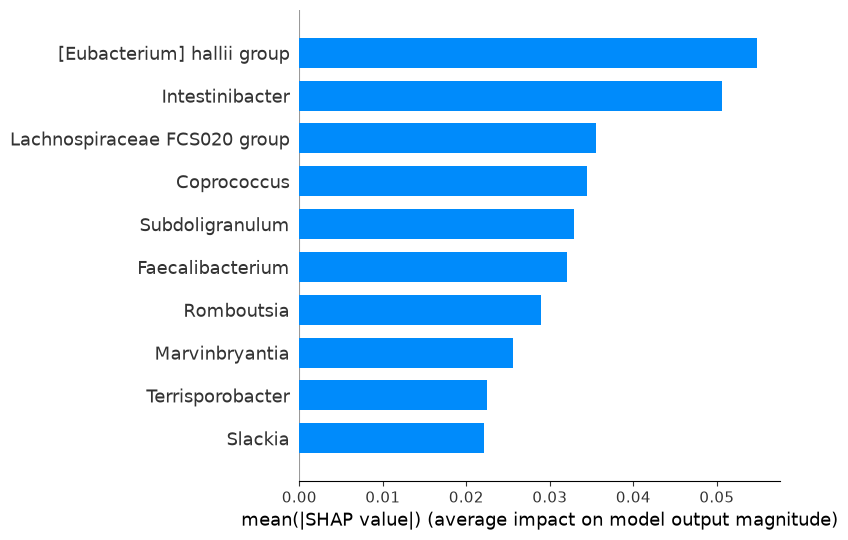

In [6]:
#mean absolute shap values

shap.summary_plot(
    shap_values[:, :, 1],
    Xte,
    plot_type="bar"
)

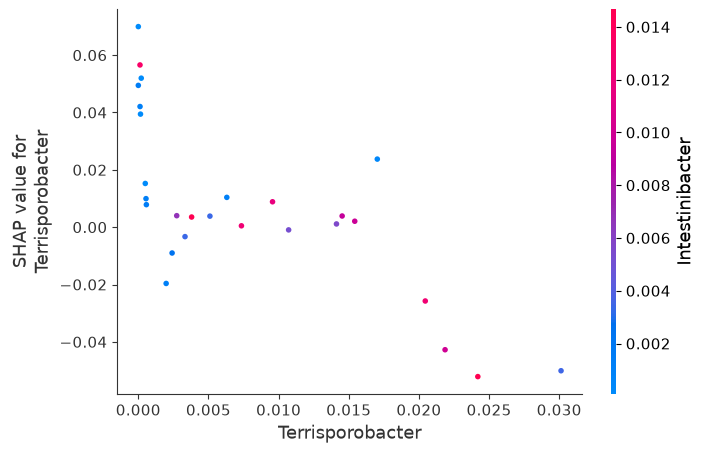

In [7]:
#shap dependencies plots 

shap.dependence_plot(
    "Terrisporobacter",
    shap_values[:, :, 1],
    Xte
)

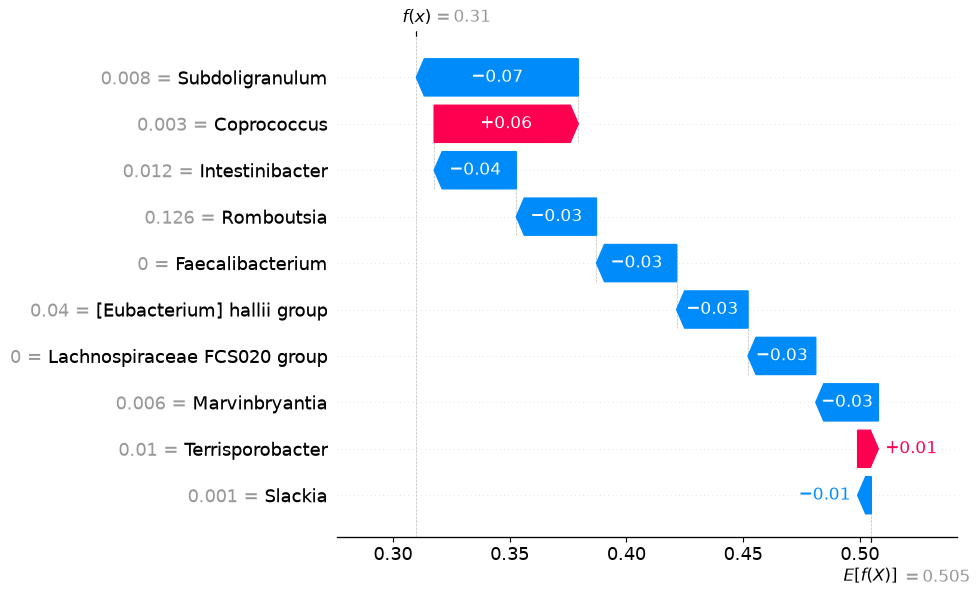

In [8]:
#local explanation

sample = 0

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample, :, 1],
        base_values=explainer.expected_value[1],
        data=Xte.iloc[sample],
        feature_names=Xte.columns
    )
)

In [11]:
#save the shap values
importance = pd.DataFrame({
    "Genus": Xte.columns,
    "Mean_SHAP": np.abs(shap_values[:, :, 1]).mean(axis=0)
})

importance = importance.sort_values(
    "Mean_SHAP",
    ascending=False
)

importance.to_csv(
    "../data/shap_importance.csv",
    index=False
)